# 020.KNN (K-Nearest Neighbors, 최근접 이웃)

### iris dataset

iris.feature_names : 

Sepal Length : 꽃받침 길이  
Sepal Width  : 꽃받침 너비   
Petal Length  : 꽃잎 길이  
Petal Width   :  꽃잎 너비 

Species (꽃의 종류) :  setosa / versicolor / virginica 의 3종류로 구분된다.

**꽃받침 길이, 너비 두가지 feature 를 가지고 KNN 알고리즘을 이용하여 꽃의 종류 분류**

**neighbors.KNeighborsClassifier(n_neighbors, weights=weights)**

- weights :  

    - uniform : uniform weights. 모든 neighbor 의 가중치를 동일하게 취급  
    - distance : neighbor 의 거리에 반비례하여 가중치 조정

필요한 라이브러리를 import 합니다. KNN 분류기와 iris 데이터셋을 사용합니다.

In [1]:
import numpy as np
from sklearn import neighbors, datasets

iris 데이터셋을 로드하고 데이터의 구조를 확인합니다. 150개의 샘플과 4개의 특성을 가진 꽃 분류 데이터입니다.

In [2]:
iris = datasets.load_iris()

print(iris.data.shape)
print(iris.feature_names)
print(iris.target_names)

(150, 4)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


시각화를 위해 꽃받침 길이와 너비 두 가지 특성만 선택합니다. 이 두 특성으로 꽃의 종류를 분류합니다.

In [3]:
# 꽃받침 길이, 너비 두가지 feature 선택
X = iris.data[:, :2]
y = iris.target

print(X[:5])
print()
print(y[:5])

[[5.1 3.5]
 [4.9 3. ]
 [4.7 3.2]
 [4.6 3.1]
 [5.  3.6]]

[0 0 0 0 0]


데이터를 훈련용과 테스트용으로 무작위 분할합니다. 기본적으로 75%는 훈련, 25%는 테스트 데이터로 나뉩니다.

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(X, y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((112, 2), (38, 2), (112,), (38,))

### KNN object 생성 및 train

KNN 분류기를 생성합니다. n_neighbors=15는 가장 가까운 15개의 이웃을 참고하며, weights='uniform'은 모든 이웃의 가중치를 동일하게 취급합니다.

In [5]:
clf = neighbors.KNeighborsClassifier(n_neighbors=15, weights='uniform')
clf.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


학습된 KNN 모델을 사용하여 테스트 데이터에 대한 예측을 수행합니다. 각 테스트 샘플의 가장 가까운 15개 이웃을 찾아 다수결로 분류합니다.

In [6]:
y_predict = clf.predict(X_test)
y_predict

array([1, 2, 2, 1, 1, 2, 0, 2, 2, 0, 2, 0, 0, 1, 0, 0, 2, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 1, 1])

혼동 행렬(confusion matrix)을 생성하여 예측 결과를 상세히 분석합니다. 행은 실제 클래스, 열은 예측 클래스를 나타냅니다.

Confusion Matrix:
[[15  0  0]
 [ 0  7  3]
 [ 1  3  9]]


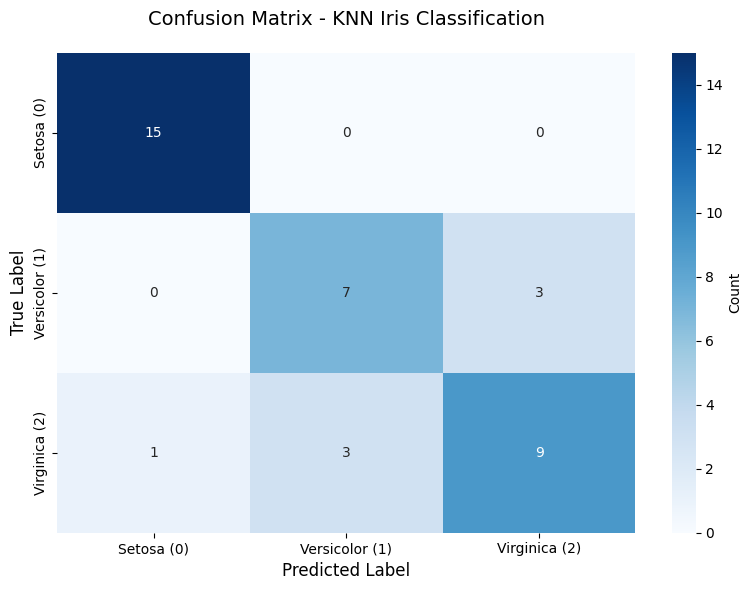

In [7]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_predict)

print("Confusion Matrix:")
print(cm)

# 시각화
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=['Setosa (0)', 'Versicolor (1)', 'Virginica (2)'],
                 yticklabels=['Setosa (0)', 'Versicolor (1)', 'Virginica (2)'],
                 cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - KNN Iris Classification', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### 예측의 정확도 평가

정확도 평가를 위한 함수를 import 합니다. accuracy_score는 전체 예측 중 올바르게 예측한 비율을 계산합니다.

In [8]:
from sklearn.metrics import accuracy_score

모델의 정확도를 계산합니다. 1에 가까울수록 좋은 성능을 의미합니다.

In [9]:
accuracy_score(y_test, y_predict)

0.8157894736842105